# Homework 7.  Programming on Embedding


## Objective
By the end of this exercise, you will be able to:
Load, explore, and visualise word embeddings to understand semantic similarity.
Solve analogies using vector arithmetic.

Please try to work out your solution first. An expected solution will be provided in one week.

### Prerequisites & Setup
Ensure you have `gensim`, `torch`, `scikit-learn`, `matplotlib`, and `numpy` installed.

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import gensim.downloader as api

## Task : Word Embeddings (Static Semantic Spaces)

Word embeddings map discrete words to dense vectors of real numbers, capturing semantic meaning based on context. We will use gensim to explore a pre-trained model.


### Task 1: Loading and Exploring Vectors


Using the gensim.downloader API, load the glove-wiki-gigaword-50 dataset (a lightweight embedding model).

1. Write a function to extract the embedding vector for the word "university". What is the dimensionality of this vector?

2. Use the model's built-in methods to find the top 5 most similar words to "data" and "python".


In [ ]:
from gensim.models.keyedvectors import KeyedVectors
from typing import cast

# Load the GloVe model (this may take a minute or two on first run)
print("Loading GloVe model...")
g = cast(KeyedVectors, api.load("glove-wiki-gigaword-50"))
print("Model loaded.")

Loading GloVe model...
Model loaded.


In [16]:
word = "unversity"

# 1. Extract vector for "university" and find dimensionality
# Your code
k = g.get_vector(word)
print(len(k))

# 2. Top 5 most similar words
# Your code
print(list(i[0] for i in g.most_similar("data")[0:5]))
print(list(i[0] for i in g.most_similar("python")[0:5]))

50
['information', 'tracking', 'database', 'analysis', 'applications']
['reticulated', 'spamalot', 'php', 'owl', 'mouse']


### Task 2: Vector Arithmetic

One of the most powerful features of word embeddings is their ability to capture relationships through vector math.

1. Perform the operation: $Vector("king") - Vector("man") + Vector("woman")$

2. What is the closest resulting word in the vocabulary? Does it match the expected result ("queen")?

3. Try to find two of your own analogies that work perfectly, and one that fails completely. Document why you think the failure occurred.


In [31]:
# 1 & 2. King - Man + Woman
# Hint: consider to use glove_model.most_similar
final_1 = g.get_vector("king") - g.get_vector("man") + g.get_vector("woman")
print(g.similar_by_vector(final_1, topn=5))

# [('king', 0.8859834671020508), ('queen', 0.8609582185745239), ('daughter', 0.7684512734413147), ('prince', 0.7640699744224548), ('throne', 0.7634970545768738)]

# The new vector king - man + woman still contains a large king component.
# This is better as it automatically excludes the inputs from the results:

final_2 = g.most_similar(
    positive=["king", "woman"],
    negative=["man"],
    topn=5
)

print(final_2)

# [('queen', 0.8523604273796082), ('throne', 0.7664334177970886), ('prince', 0.7592144012451172), ('daughter', 0.7473883628845215), ('elizabeth', 0.7460219860076904)]

# 3. Student analogies (Example solutions)
# Perfect analogy: Paris - France + Germany = Berlin

print(g.most_similar(
    positive=["paris", "germany"],
    negative=["france"],
    topn=1
)[0][0])


# Failed analogy example: Doctor - Man + Woman = Nurse (or similar biased result)

print(g.most_similar(
    positive=["doctor", "woman"],
    negative=["man"],
    topn=1
)[0][0]) # gendered corpus association, not a clean semantic relation


[('king', 0.8859834671020508), ('queen', 0.8609582185745239), ('daughter', 0.7684512734413147), ('prince', 0.7640699744224548), ('throne', 0.7634970545768738)]
[('queen', 0.8523604273796082), ('throne', 0.7664334177970886), ('prince', 0.7592144012451172), ('daughter', 0.7473883628845215), ('elizabeth', 0.7460219860076904)]
berlin
nurse


### Task 1.3: Visualizing Semantic Clusters

Word vectors exist in 50-dimensional space, which is impossible to visualize directly.

1. Create a list of words from three distinct categories (e.g., animals, vehicles, emotions).

2. Extract their vectors and use Principal Component Analysis (PCA) via scikit-learn to reduce them to 2 dimensions.

3. Plot the resulting 2D coordinates using matplotlib. Do the categories cluster together?


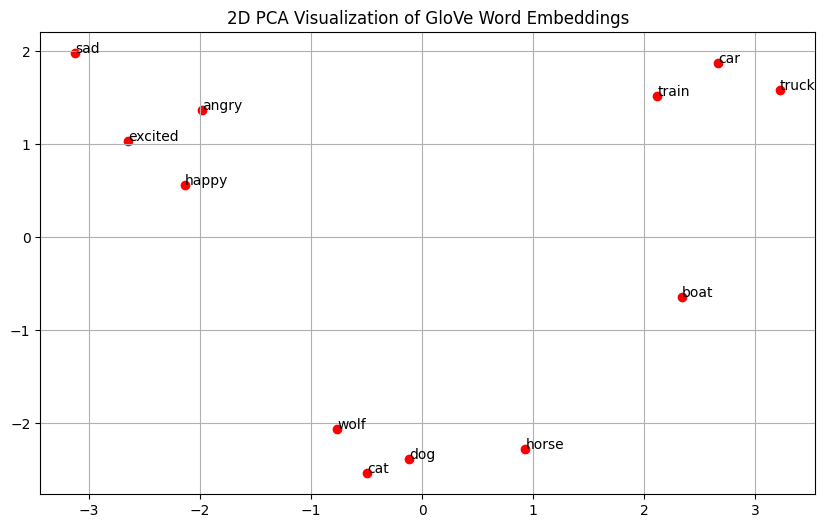

In [47]:
# 1. Categories


# Extract vectors
words = ["sad", "angry", "excited", "happy", "car", "train", "truck", "boat", "wolf", "cat", "dog", "horse"]
embeddings = np.array([g.get_vector(i) for i in words])

# print(embeddings)

# 2. PCA Reduction
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(embeddings)

# print(reduced_vectors)

# 3. Plotting
plt.figure(figsize=(10, 6))
plt.scatter(x=reduced_vectors[:,0], y=reduced_vectors[:,1], color='red')

# Annotate points
# Your code
for i in range(len(words)):
    plt.annotate(words[i], (reduced_vectors[i, 0], reduced_vectors[i, 1]))

plt.title("2D PCA Visualization of GloVe Word Embeddings")
plt.grid(True)
plt.show()